# Cyberbullying Tweet Classification Experiment

This notebook applies the same NLP pipeline used in the fake news experiment to a secondary dataset about cyberbullying tweets.

The goal is to classify tweets as either cyberbullying or not cyberbullying. The original dataset contains multiple cyberbullying categories, but this experiment converts the task into a binary classification problem:

- `0 = Not Cyberbullying`
- `1 = Cyberbullying`

This allows the same TF-IDF, sentiment, and Random Forest pipeline to be compared with the fake news classification experiment.

In [1]:
import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split
from textblob import TextBlob

In [8]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nathn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nathn\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nathn\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
df = pd.read_csv("data/cyberbullying_tweets.csv")

df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [5]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df["cyberbullying_type"].value_counts())

(47692, 2)
Index(['tweet_text', 'cyberbullying_type'], dtype='str')
tweet_text            0
cyberbullying_type    0
dtype: int64
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


In [6]:
df["label"] = df["cyberbullying_type"].apply(
    lambda x: 0 if x == "not_cyberbullying" else 1
)

df[["tweet_text", "cyberbullying_type", "label"]].head()

,tweet_text,cyberbullying_type,label
0,"In other words #katandandre, your food was cra...",not_cyberbullying,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,0
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,0
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,0


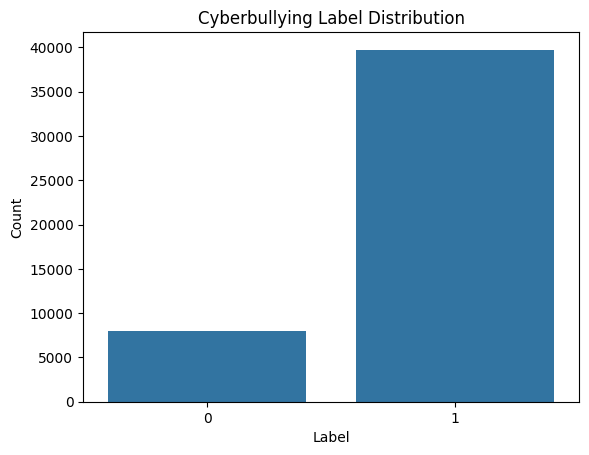

In [7]:
sns.countplot(x="label", data=df)

plt.title("Cyberbullying Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [9]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [10]:
def clean_text(text):
    """
    Cleans and preprocesses text data.
    """

    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(cleaned_words)

In [11]:
df["clean_text"] = df["tweet_text"].apply(clean_text)

df[["tweet_text", "clean_text", "label"]].head()

,tweet_text,clean_text,label
0,"In other words #katandandre, your food was cra...",word katandandre food crapilicious mkr,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,aussietv white mkr theblock imacelebrityau tod...,0
2,@XochitlSuckkks a classy whore? Or more red ve...,xochitlsuckkks classy whore red velvet cupcake,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",jasongio meh p thanks head concerned another a...,0
4,@RudhoeEnglish This is an ISIS account pretend...,rudhoeenglish isi account pretending kurdish a...,0


In [12]:
df = df[df["clean_text"].str.strip() != ""]

print(df.shape)

(47653, 4)


In [13]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 38122
Testing rows: 9531


In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (38122, 5000)
Testing TF-IDF shape: (9531, 5000)


In [15]:
train_sentiment = X_train.apply(
    lambda text: TextBlob(text).sentiment.polarity
)

test_sentiment = X_test.apply(
    lambda text: TextBlob(text).sentiment.polarity
)

print(train_sentiment.head())

23635   -0.178571
31904    0.000000
36314   -0.100000
30174   -0.100000
34930   -0.023333
Name: clean_text, dtype: float64


In [16]:
X_train_combined = hstack([
    X_train_tfidf,
    train_sentiment.values.reshape(-1, 1)
])

X_test_combined = hstack([
    X_test_tfidf,
    test_sentiment.values.reshape(-1, 1)
])

print("Training combined shape:", X_train_combined.shape)
print("Testing combined shape:", X_test_combined.shape)

Training combined shape: (38122, 5001)
Testing combined shape: (9531, 5001)


In [17]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_combined, y_train)

print("Model training complete.")

Model training complete.


In [18]:
y_pred = model.predict(X_test_combined)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.38      0.46      1587
           1       0.88      0.94      0.91      7944

    accuracy                           0.85      9531
   macro avg       0.73      0.66      0.69      9531
weighted avg       0.83      0.85      0.84      9531



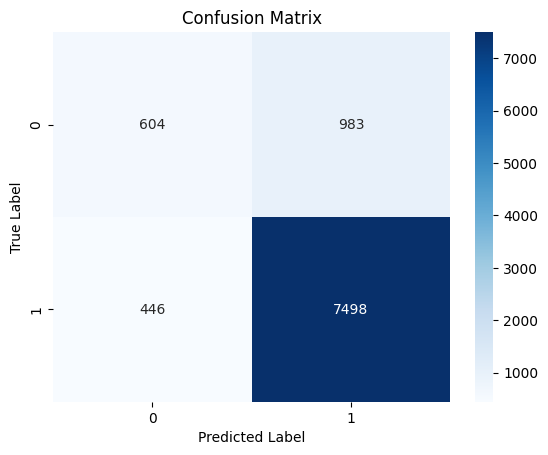

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [20]:
cv_scores = cross_val_score(
    model,
    X_train_combined,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:")
print(cv_scores)

print("\nAverage F1 score:")
print(cv_scores.mean())

Cross-validation F1 scores:
[0.9168437  0.91495334 0.91667301 0.91652055 0.91626812]

Average F1 score:
0.9162517445407274


## Results Discussion

The Random Forest model performed differently on the cyberbullying dataset compared to the fake news dataset. The overall accuracy was still relatively high, but the model struggled more when identifying non-cyberbullying tweets. Precision and recall for the cyberbullying class were strong, while the non-cyberbullying class was harder to classify correctly.

TF-IDF still worked well because it captured important words and patterns commonly used in harmful tweets. However, cyberbullying language is more informal and complex than fake news articles. Tweets often contain slang, abbreviations, sarcasm, hashtags, usernames, and short sentences, which makes preprocessing more difficult.

One challenge during preprocessing was cleaning noisy social media text without removing too much useful meaning. Some tweets also contained mixed context where offensive words were used jokingly or conversationally, making classification harder.

The Random Forest model performed reasonably well overall, but not as perfectly as it did on the fake news dataset. This suggests that cyberbullying detection is a more difficult NLP problem because harmful intent is not always obvious from the text alone.

## Comparison Between Datasets

The fake news dataset produced much higher classification performance than the cyberbullying dataset. One reason is that fake news articles often contain stronger wording patterns and more structured language, making them easier for TF-IDF and Random Forest to separate.

The cyberbullying dataset was more challenging because tweets are shorter, noisier, and more informal. Social media language contains slang, abbreviations, sarcasm, hashtags, and usernames that make text preprocessing and classification harder.

Both datasets demonstrated that TF-IDF and Random Forest are effective for NLP classification tasks, but the results also showed how dataset complexity and writing style can strongly affect model performance.